# 6: Probability Distributions (06_Probability_Distributions.ipynb)

**Sprint:** Sprint 2 – Statistics & Mathematics for AI/ML Engineers

## 1. Bernoulli Distribution

### Definition
A Bernoulli Distribution models a SINGLE trial with exactly TWO 
possible outcomes - success (1) or failure (0). It's the simplest 
possible probability distribution.

### Formula
P(X=1) = p, P(X=0) = 1-p
Where p = probability of success

### Where it is used
Used to model any single yes/no, true/false, pass/fail event - the 
building block for more complex distributions like Binomial.

### Real-World Example
A single coin flip: P(Heads) = 0.5, P(Tails) = 0.5. Or whether a 
single customer clicks an ad (click = 1, no click = 0).

### AI/ML Example
The output of a binary classifier (spam/not spam, fraud/not fraud) 
is fundamentally a Bernoulli random variable - the model predicts 
a probability p, and the actual outcome is 0 or 1.

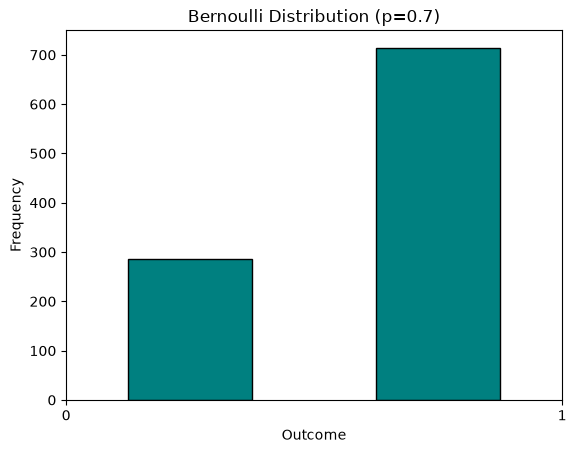

Proportion of successes (should be close to 0.7): 0.714


In [1]:
import numpy as np
import matplotlib.pyplot as plt

p = 0.7   # probability of success
samples = np.random.binomial(n=1, p=p, size=1000)   # Bernoulli = Binomial with n=1

plt.hist(samples, bins=2, color="teal", edgecolor="black", rwidth=0.5)
plt.title("Bernoulli Distribution (p=0.7)")
plt.xticks([0, 1])
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.show()

print("Proportion of successes (should be close to 0.7):", np.mean(samples))

# Where it's used: np.random.binomial(n=1, p=0.7, size=1000) with
# n=1 generates Bernoulli trials - each is a single 0/1 outcome.
# The histogram shows roughly 70% of samples are 1 (success),
# matching our set probability p=0.7.

## 2. Binomial Distribution

### Definition
A Binomial Distribution models the number of SUCCESSES across a 
FIXED NUMBER of independent Bernoulli trials (repeated yes/no 
experiments) - essentially, Bernoulli repeated n times.

### Formula
P(X=k) = C(n,k) × p^k × (1-p)^(n-k)
Where n = number of trials, k = number of successes, p = probability of success

### Where it is used
Used whenever you're counting successes across multiple repeated 
independent trials - like counting heads across multiple coin flips.

### Real-World Example
Flipping a coin 10 times and counting how many times it lands 
Heads - the total count of heads follows a Binomial Distribution.

### AI/ML Example
Used in A/B testing to model the number of conversions (successes) 
out of a fixed number of website visitors (trials), helping 
determine if a new feature genuinely improves conversion rates.

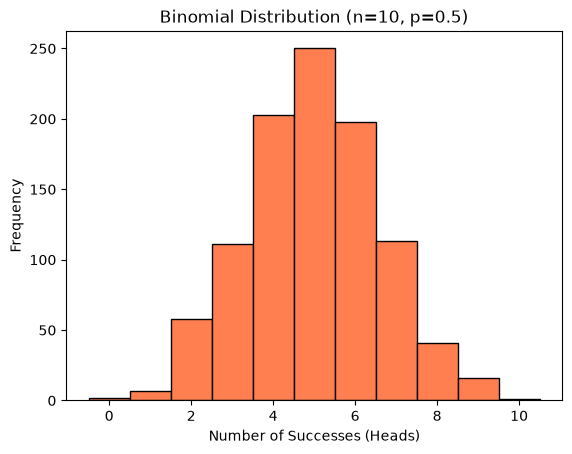

Average number of successes (should be close to n*p = 5.0 ): 4.979


In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = 10    # 10 trials (coin flips)
p = 0.5   # fair coin
samples = np.random.binomial(n=n, p=p, size=1000)

plt.hist(samples, bins=range(0, n+2), color="coral", edgecolor="black", align="left")
plt.title(f"Binomial Distribution (n={n}, p={p})")
plt.xlabel("Number of Successes (Heads)")
plt.ylabel("Frequency")
plt.show()

print("Average number of successes (should be close to n*p =", n*p, "):", np.mean(samples))

# Where it's used: np.random.binomial(n=10, p=0.5, size=1000)
# simulates flipping a coin 10 times, repeated 1000 times, counting
# heads each time. The histogram peaks around 5 (n*p = 10*0.5),
# confirming the expected number of successes matches theory.

## 3. Poisson Distribution

### Definition
A Poisson Distribution models the number of times an EVENT occurs 
within a FIXED interval of time or space, when events happen 
independently and at a constant average rate.

### Formula
P(X=k) = (λ^k × e^(-λ)) / k!
Where λ (lambda) = average number of events per interval

### Where it is used
Used for counting rare, independent events over a fixed period - 
like the number of calls a call center receives per hour, or the 
number of website crashes per day.

### Real-World Example
A hospital emergency room receives an average of 5 patients per 
hour. The Poisson Distribution models the probability of receiving 
exactly 3, 7, or any specific number of patients in a given hour.

### AI/ML Example
Poisson Distribution is used in anomaly detection systems - 
modeling the "normal" expected rate of events (like server 
requests or transactions), so a rate significantly higher than 
expected can be flagged as unusual.

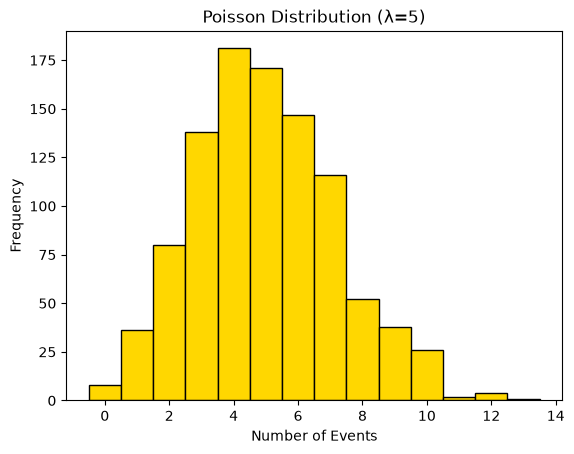

Average events (should be close to λ = 5 ): 4.984


In [3]:
import numpy as np
import matplotlib.pyplot as plt

lam = 5   # average 5 events per interval
samples = np.random.poisson(lam=lam, size=1000)

plt.hist(samples, bins=range(0, 15), color="gold", edgecolor="black", align="left")
plt.title(f"Poisson Distribution (λ={lam})")
plt.xlabel("Number of Events")
plt.ylabel("Frequency")
plt.show()

print("Average events (should be close to λ =", lam, "):", np.mean(samples))

# Where it's used: np.random.poisson(lam=5, size=1000) simulates
# 1000 intervals, each with a random count of events averaging 5.
# The histogram peaks around 5, and its slightly right-skewed shape
# (not perfectly symmetric) is a hallmark of Poisson distributions.

## 4. Uniform Distribution (formal treatment)

### Definition
Every value within a fixed range [a, b] has an EQUAL probability of 
occurring - no value is more likely than any other.

### Formula
f(x) = 1 / (b - a), for a ≤ x ≤ b

### Where it is used
Used when there's no reason to believe any outcome is more likely 
than another within a range - like random number generation.

### Real-World Example
A random number generator producing any decimal between 0 and 1, 
where every value is equally likely.

### AI/ML Example
Uniform Distribution is used to initialize model weights before 
training in some neural networks, and it underlies most random 
sampling functions used for train/test splitting.

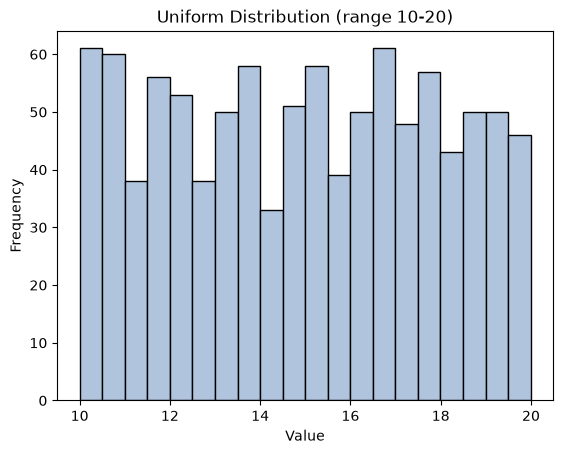

Mean (should be close to (a+b)/2 = 15.0 ): 14.934488784506307


In [4]:
import numpy as np
import matplotlib.pyplot as plt

a, b = 10, 20   # range
samples = np.random.uniform(low=a, high=b, size=1000)

plt.hist(samples, bins=20, color="lightsteelblue", edgecolor="black")
plt.title(f"Uniform Distribution (range {a}-{b})")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

print("Mean (should be close to (a+b)/2 =", (a+b)/2, "):", np.mean(samples))

# Where it's used: np.random.uniform(low=10, high=20, size=1000)
# generates values evenly spread across the range - the histogram
# bars are roughly EQUAL height throughout, confirming no value is
# favored over another, unlike Poisson or Binomial's peaked shapes.

## 5. Normal Distribution (formal treatment)

### Definition
A symmetric, bell-shaped distribution where values cluster around 
the mean, with probability decreasing symmetrically as you move 
further away in either direction.

### Formula
f(x) = (1 / (σ√(2π))) × e^(-(x-μ)² / (2σ²))
Where μ = mean, σ = standard deviation

### Where it is used
Used for naturally occurring continuous data that tends to cluster 
around an average - heights, test scores, measurement errors.

### Real-World Example
IQ scores across a population follow a Normal Distribution, 
centered around 100, with most people scoring within a moderate 
range of that average.

### AI/ML Example
Linear Regression assumes residuals (prediction errors) are 
normally distributed. Feature Standardization transforms data to 
follow a standard normal distribution (mean=0, std=1) before 
feeding it into many ML algorithms.

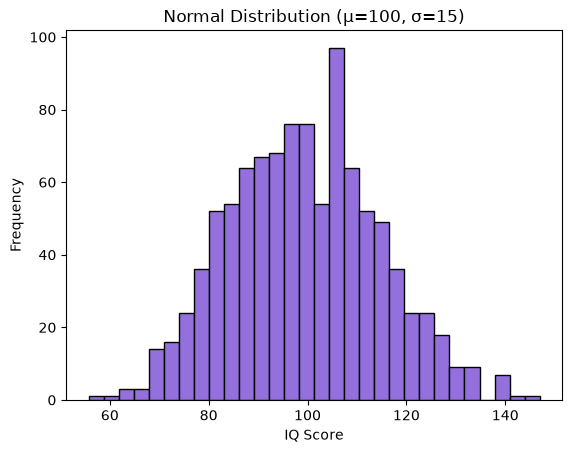

Mean (should be close to 100 ): 99.42309064015872


In [5]:
import numpy as np
import matplotlib.pyplot as plt

mu, sigma = 100, 15   # IQ scores: mean=100, std=15
samples = np.random.normal(loc=mu, scale=sigma, size=1000)

plt.hist(samples, bins=30, color="mediumpurple", edgecolor="black")
plt.title(f"Normal Distribution (μ={mu}, σ={sigma})")
plt.xlabel("IQ Score")
plt.ylabel("Frequency")
plt.show()

print("Mean (should be close to", mu, "):", np.mean(samples))

# Where it's used: np.random.normal(loc=100, scale=15, size=1000)
# simulates 1000 IQ scores. The histogram's classic bell shape,
# centered near 100, confirms the defining symmetric clustering
# behavior of a Normal Distribution.

## 6. Exponential Distribution

### Definition
Models the TIME between events in a process where events happen 
continuously and independently at a constant average rate - 
closely related to the Poisson Distribution, but measuring TIME 
BETWEEN events, not event COUNTS.

### Formula
f(x) = λ × e^(-λx), for x ≥ 0
Where λ = rate parameter (average number of events per unit time)

### Where it is used
Used to model waiting times - time until the next customer arrives, 
time until a machine part fails, time between website visits.

### Real-World Example
The time between customers arriving at a store follows an 
Exponential Distribution - most gaps are short, but occasionally 
there's a long wait, creating a right-skewed shape.

### AI/ML Example
Exponential Distribution is used in survival analysis and 
reliability modeling - predicting the probability a machine 
component survives beyond a certain time, common in predictive 
maintenance ML systems.

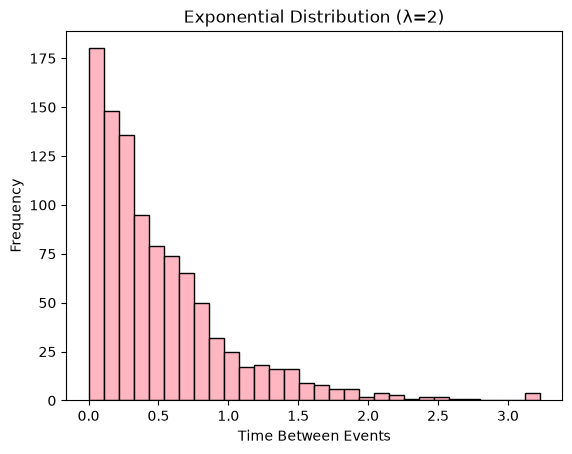

Mean time between events (should be close to 1/λ = 0.5 ): 0.5121143652849904


In [6]:
import numpy as np
import matplotlib.pyplot as plt

rate = 2   # average 2 events per unit time
samples = np.random.exponential(scale=1/rate, size=1000)   # scale = 1/lambda

plt.hist(samples, bins=30, color="lightpink", edgecolor="black")
plt.title(f"Exponential Distribution (λ={rate})")
plt.xlabel("Time Between Events")
plt.ylabel("Frequency")
plt.show()

print("Mean time between events (should be close to 1/λ =", 1/rate, "):", np.mean(samples))

# Where it's used: np.random.exponential(scale=1/rate, size=1000)
# simulates waiting times. The histogram is heavily RIGHT-skewed -
# most wait times are short, but a few are much longer, the
# characteristic shape of an Exponential Distribution, unlike the
# symmetric Normal Distribution.

## Interview Questions - Probability Distributions

**Q1: What is a Bernoulli Distribution?**
A distribution modeling a single trial with exactly two outcomes - 
success (1) or failure (0), with probability p of success.

**Q2: How is the Binomial Distribution related to the Bernoulli 
Distribution?**
Binomial is essentially the Bernoulli distribution repeated n 
times - it models the total number of successes across n 
independent Bernoulli trials.

**Q3: What does the Poisson Distribution model?**
The number of times an event occurs in a fixed interval of time or 
space, given events happen independently at a constant average rate.

**Q4: What's the key difference between Poisson and Exponential 
Distributions?**
Poisson models the COUNT of events in a fixed interval. Exponential 
models the TIME BETWEEN events - they're related but measure 
different things.

**Q5: When would you use a Uniform Distribution instead of a 
Normal Distribution?**
When every outcome in a range is equally likely, with no 
clustering around any particular value - e.g., random number 
generation, unlike Normal's bell-shaped clustering.

**Q6: Why is the Normal Distribution so important in statistics 
and ML?**
Many natural phenomena approximate it, many statistical tests 
assume it, and many ML algorithms (like Linear Regression) rely on 
normally distributed errors for their mathematical guarantees to hold.

**Q7: What does λ (lambda) represent in a Poisson Distribution?**
The average number of events expected to occur in the given interval.

**Q8: Give a real-world example of an Exponential Distribution.**
The time between customer arrivals at a store, or the time until a 
machine component fails - most gaps are short, with occasional 
longer waits (right-skewed).

**Q9: How is Bernoulli Distribution connected to binary 
classification in ML?**
A binary classifier's output (spam/not spam) is fundamentally a 
Bernoulli random variable - the model predicts probability p, and 
the true label is 0 or 1.

**Q10: Why would a data scientist choose a Poisson Distribution to 
model website traffic spikes rather than a Normal Distribution?**
Website events (like requests) are discrete counts over time 
intervals with a constant average rate - Poisson is built 
specifically for this, while Normal assumes continuous, 
symmetrically distributed data, which doesn't fit count data well.